# Notebook 02 — Preprocessing (Rebuild 2026)

| | |
|---|---|
| **Projet** | Application Intelligente de Scoring Client |
| **Entreprise** | Orus Services — filiale Salafin, Bank of Africa |
| **Auteure** | Fatima Zahra Ait Lamine |
| **Année** | PFE 2025–2026 (rebuild du pipeline ML) |

---

## Objectif

Implémenter le preprocessing validé par l'audit de la **phase 1** (`docs/phase1_dataset_audit.md`),
avec trois exigences supplémentaires :

1. **Chaque seuil de winsorisation est justifié statistiquement** (percentiles, borne IQR, sémantique du Data Dictionary) — aucune valeur arbitraire.
2. **Un tableau récapitulatif** feature → traitement → justification, prêt pour le rapport.
3. **Chaque contrainte monotone est vérifiée empiriquement** sur les données nettoyées avant d'être imposée au modèle (phase 3).

## Ordre anti-fuite (data leakage)

| # | Étape | Position vs split | Pourquoi |
|---|---|---|---|
| 1 | Suppression `age==0` + doublons exacts | **Avant** | Suppression de lignes d'entraînement, aucun paramètre estimé ; les doublons doivent partir AVANT le split sinon une même ligne peut tomber en train ET en test |
| 2 | Split stratifié 80/20 | — | Le test (20 %) n'est plus touché avant la phase 4 |
| 3 | Nettoyage sémantique (sentinelles, placeholders, ratios invalides) | Indifférent | Constantes du Data Dictionary, aucune statistique |
| 4 | Winsorisation (p99.5 revenus, p99 DebtRatio, p99.9 personnes à charge) | **Après — fit sur train** | Percentiles = statistiques → estimés sur train uniquement |
| 5 | Imputation médiane (modèles qui l'exigent) | **Après — fit sur train** | Idem |

> La cible est `SeriousDlqin2yrs` (binaire). Les niveaux FAIBLE/MOYEN/ÉLEVÉ de l'application
> seront dérivés de la **probabilité calibrée** en phase 6 — jamais reconstruits à partir des
> features (c'était la circularité du pipeline précédent).

> **Note :** le scaling (nécessaire à la régression logistique) et l'imputation sont intégrés
> aux pipelines de modèles de la phase 3, à l'intérieur de la validation croisée — ils sont
> donc ré-estimés dans chaque fold, ce qui élimine tout risque de fuite via la CV.

## 1. Imports et chargement

In [1]:
import sys, os, pickle, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../src'))
from preprocessing import (clean_gmsc, drop_training_rows, FittedPreprocessor,
                           FEATURE_COLS, RAW_FEATURES, DELAY_COLS, TARGET,
                           MONOTONE_CONSTRAINTS, SENTINEL_VALUES)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11, 'axes.titleweight': 'bold'})
os.makedirs('figures', exist_ok=True)

RAW_PATH = '../data/GiveMeSomeCredit-training.csv'
raw = pd.read_csv(RAW_PATH, index_col=0)
print(f"Fichier source : {RAW_PATH}")
print(f"Dimensions     : {raw.shape[0]:,} lignes × {raw.shape[1]} colonnes")
print(f"Taux de défaut : {raw[TARGET].mean()*100:.2f}%")

Fichier source : ../data/GiveMeSomeCredit-training.csv
Dimensions     : 150,000 lignes × 11 colonnes
Taux de défaut : 6.68%


## 2. Étape 1 — Nettoyage structurel (avant split)

Deux suppressions de lignes, réservées aux données d'entraînement :
- **`age == 0`** : 1 ligne, erreur de saisie (seule valeur < 21 du fichier).
- **Doublons exacts** (les 11 colonnes identiques) : s'ils survivent au split, le modèle est
  évalué sur des lignes qu'il a mémorisées. Les 37 groupes à features identiques mais **labels
  contradictoires** sont conservés : ce sont des personnes différentes aux caractéristiques
  mesurées identiques (bruit aléatoire irréductible, pas une erreur).

In [2]:
df = drop_training_rows(raw)
print(f"Lignes : {len(raw):,} → {len(df):,}  (retirées : {len(raw)-len(df):,} = 1 age==0 + {len(raw)-len(df)-1} doublons)")

Lignes : 150,000 → 149,390  (retirées : 610 = 1 age==0 + 609 doublons)


## 3. Étape 2 — Split stratifié 80 / 20

- **80 % train** : toutes les statistiques, l'entraînement et la CV 5-fold de la phase 3.
- **20 % test** : intouché jusqu'à l'évaluation finale (phase 4).

La stratification garantit le même taux de défaut (6.70 %) des deux côtés.
**Toutes les statistiques des sections suivantes sont calculées sur le train uniquement.**

In [3]:
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df[TARGET])
print(f"Train : {len(train_df):,} lignes — défaut {train_df[TARGET].mean()*100:.3f}%")
print(f"Test  : {len(test_df):,} lignes — défaut {test_df[TARGET].mean()*100:.3f}%")

Train : 119,512 lignes — défaut 6.700%


Test  : 29,878 lignes — défaut 6.701%


## 4. Étape 3 — Justification statistique de chaque seuil

Pour chaque variable problématique on confronte trois références : les **percentiles** de la
distribution, la **borne IQR** (Q3 + 1.5×IQR), et la **sémantique métier** du Data Dictionary —
puis on vérifie ce que dit le **taux de défaut observé** dans chaque zone.

In [4]:
def taux_par_bande(dfx, col, edges, titre):
    b = pd.cut(dfx[col], edges, include_lowest=True)
    g = dfx.groupby(b, observed=True)[TARGET].agg(taux_defaut='mean', effectif='count')
    g['taux_defaut'] = (g['taux_defaut']*100).round(2)
    print(f"— {titre}")
    print(g.to_string(), "\n")
    return g

def fence_iqr(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    return q3 + 1.5*(q3-q1)

# ── 4a. RevolvingUtilizationOfUnsecuredLines ─────────────────────────────
ru = train_df['RevolvingUtilizationOfUnsecuredLines']
print(f"Percentiles : p99={ru.quantile(.99):.3f} | p99.5={ru.quantile(.995):.3f} | borne IQR={fence_iqr(ru):.3f} | max={ru.max():,.0f}")
_ = taux_par_bande(train_df, 'RevolvingUtilizationOfUnsecuredLines',
                   [0, 0.5, 1.0, 1.09, 1.5, 2, 10, ru.max()],
                   "Taux d'utilisation — taux de défaut par zone")
print("Lecture : le risque MONTE jusqu'à ~48% sur (1.09, 1.5] et reste ~45% sur (1.5, 2]")
print("(dépassement de plafond réel), puis S'EFFONDRE au-delà de 2 (24.8%) et surtout de 10")
print("(5.6% ≈ taux de base) → les valeurs >2 ne sont pas des 'utilisations extrêmes',")
print("ce sont des valeurs corrompues (probablement des soldes absolus).")
print("DÉCISION : >2 → NaN (0.23% des lignes). Le Data Dictionary définit un ratio ;")
print("un dépassement jusqu'à 2× le plafond est opérationnellement possible, au-delà non.")

Percentiles : p99=1.091 | p99.5=1.347 | borne IQR=1.345 | max=50,708
— Taux d'utilisation — taux de défaut par zone
                                      taux_defaut  effectif
RevolvingUtilizationOfUnsecuredLines                       
(-0.001, 0.5]                                2.74     86744
(0.5, 1.0]                                  15.47     30118
(1.0, 1.09]                                 34.44      1449
(1.09, 1.5]                                 48.16       733
(1.5, 2.0]                                  45.21       188
(2.0, 10.0]                                 24.75       101
(10.0, 50708.0]                              5.59       179 

Lecture : le risque MONTE jusqu'à ~48% sur (1.09, 1.5] et reste ~45% sur (1.5, 2]
(dépassement de plafond réel), puis S'EFFONDRE au-delà de 2 (24.8%) et surtout de 10
(5.6% ≈ taux de base) → les valeurs >2 ne sont pas des 'utilisations extrêmes',
ce sont des valeurs corrompues (probablement des soldes absolus).
DÉCISION : >2 → NaN (0.23% de

In [5]:
# ── 4b. MonthlyIncome : placeholders 0 et 1 ──────────────────────────────
inc = train_df['MonthlyIncome']
zones = [('manquant (NaN)', inc.isna()), ('== 0', inc == 0), ('== 1', inc == 1), ('> 1', inc > 1)]
print(f"{'zone':<15} {'n':>8} {'défaut %':>9} {'médiane DebtRatio':>18}")
for lab, m in zones:
    print(f"{lab:<15} {m.sum():>8,} {train_df.loc[m, TARGET].mean()*100:>8.2f}% "
          f"{train_df.loc[m, 'DebtRatio'].median():>18,.3f}")
print()
print("Lecture : les lignes revenu 0/1 se comportent comme le groupe 'manquant'")
print("(défaut 3.8%/3.0% vs 5.5%, contre 7.1% pour les vrais revenus) et leur DebtRatio")
print("médian (956 / 600) est une somme absolue, pas un ratio.")
print("DÉCISION : revenu ≤ 1 → NaN, couvert par l'indicateur income_missing.")

zone                   n  défaut %  médiane DebtRatio
manquant (NaN)    23,351     5.53%          1,198.000
== 0               1,290     3.80%            956.000
== 1                 469     2.99%            600.000
> 1               94,402     7.05%              0.291

Lecture : les lignes revenu 0/1 se comportent comme le groupe 'manquant'
(défaut 3.8%/3.0% vs 5.5%, contre 7.1% pour les vrais revenus) et leur DebtRatio
médian (956 / 600) est une somme absolue, pas un ratio.
DÉCISION : revenu ≤ 1 → NaN, couvert par l'indicateur income_missing.


In [6]:
# ── 4c. DebtRatio : validité conditionnelle au revenu + plafond p99 ──────
valid = train_df['MonthlyIncome'].notna() & (train_df['MonthlyIncome'] > 1)
dr = train_df.loc[valid, 'DebtRatio']
print(f"Lignes à ratio VALIDE (revenu connu > 1) : {valid.sum():,} ({valid.mean()*100:.1f}% du train)")
print(f"Percentiles (ratios valides) : p95={dr.quantile(.95):.3f} | p99={dr.quantile(.99):.3f} | "
      f"p99.5={dr.quantile(.995):.3f} | borne IQR={fence_iqr(dr):.3f} | max={dr.max():,.0f}")
_ = taux_par_bande(train_df[valid], 'DebtRatio', [0,.2,.4,.6,.8,1,1.5,2,3,dr.max()],
                   'DebtRatio (revenu valide) — taux de défaut par zone')
print("Lecture : le risque culmine sur (1.5, 2] à 14.6% puis DÉCROÎT (10.3% puis 7.9%).")
print("Au-delà de ~2 les valeurs n'apportent plus d'ordre de risque → winsorisation au p99")
print(f"(={dr.quantile(.99):.2f} ≈ 2, cohérent avec la borne métier « charges = 2× revenu brut »).")
print("DÉCISION : DebtRatio → NaN si revenu invalide ; sinon plafonné au p99 du train.")

Lignes à ratio VALIDE (revenu connu > 1) : 94,402 (79.0% du train)


Percentiles (ratios valides) : p95=0.943 | p99=2.016 | p99.5=3.093 | borne IQR=0.962 | max=450
— DebtRatio (revenu valide) — taux de défaut par zone
                taux_defaut  effectif
DebtRatio                            
(-0.001, 0.2]          6.14     32466
(0.2, 0.4]             5.68     30659
(0.4, 0.6]             7.67     17206
(0.6, 0.8]            10.43      7002
(0.8, 1.0]            12.04      2974
(1.0, 1.5]            13.21      2445
(1.5, 2.0]            14.60       692
(2.0, 3.0]            10.28       467
(3.0, 450.333]         7.94       491 

Lecture : le risque culmine sur (1.5, 2] à 14.6% puis DÉCROÎT (10.3% puis 7.9%).
Au-delà de ~2 les valeurs n'apportent plus d'ordre de risque → winsorisation au p99
(=2.02 ≈ 2, cohérent avec la borne métier « charges = 2× revenu brut »).
DÉCISION : DebtRatio → NaN si revenu invalide ; sinon plafonné au p99 du train.


In [7]:
# ── 4d. MonthlyIncome : plafond p99.5 ─────────────────────────────────────
iv = train_df.loc[valid, 'MonthlyIncome']
p995 = iv.quantile(.995)
print(f"Percentiles (revenus valides) : p99={iv.quantile(.99):,.0f} | p99.5={p995:,.0f} | "
      f"p99.9={iv.quantile(.999):,.0f} | max={iv.max():,.0f}")
haut = valid & (train_df['MonthlyIncome'] > p995)
print(f"Au-delà du p99.5 : {haut.sum()} lignes, défaut {train_df.loc[haut, TARGET].mean()*100:.2f}% "
      f"(vs {train_df.loc[valid, TARGET].mean()*100:.2f}% global) → plateau, aucun signal supplémentaire")
print(f"DÉCISION : plafond au p99.5 (≈ {p995:,.0f} $) — préserve 99.5% de la masse, neutralise")
print("le max invraisemblable (3 M$/mois) qui déstabiliserait scaler et régression logistique.")

Percentiles (revenus valides) : p99=25,083 | p99.5=35,000 | p99.9=77,232 | max=3,008,750
Au-delà du p99.5 : 468 lignes, défaut 5.77% (vs 7.05% global) → plateau, aucun signal supplémentaire
DÉCISION : plafond au p99.5 (≈ 35,000 $) — préserve 99.5% de la masse, neutralise
le max invraisemblable (3 M$/mois) qui déstabiliserait scaler et régression logistique.


In [8]:
# ── 4e. NumberOfDependents : plafond p99.9 + non-redondance du flag ───────
dep = train_df['NumberOfDependents']
print(f"p99={dep.quantile(.99):.0f} | p99.9={dep.quantile(.999):.0f} | max={dep.max():.0f}")
print("Effectifs au-delà de 6 :", {int(k): int(v) for k, v in dep.value_counts().sort_index().items() if k > 6})
print(f"DÉCISION : plafond au p99.9 (=6). Au-delà : 66 lignes — trop peu pour estimer un taux ;")
print(f"le fichier Kaggle de soumission contient même un 43, preuve d'erreurs de saisie.")
print()
dep_na = dep.isna()
inc_na = train_df['MonthlyIncome'].isna()
print(f"Chevauchement : {int((dep_na & inc_na).sum())} des {int(dep_na.sum())} lignes sans dependents "
      f"({(dep_na & inc_na).mean()/max(dep_na.mean(),1e-9)*100:.0f}%) sont AUSSI sans revenu")
print("→ sous-ensemble strict : income_missing suffit, pas de second indicateur.")

p99=4 | p99.9=6 | max=10
Effectifs au-delà de 6 : {7: 40, 8: 17, 9: 5, 10: 4}
DÉCISION : plafond au p99.9 (=6). Au-delà : 66 lignes — trop peu pour estimer un taux ;
le fichier Kaggle de soumission contient même un 43, preuve d'erreurs de saisie.

Chevauchement : 3087 des 3087 lignes sans dependents (100%) sont AUSSI sans revenu
→ sous-ensemble strict : income_missing suffit, pas de second indicateur.


In [9]:
# ── 4f. Sentinelles 96/98 et compteurs de retards ─────────────────────────
sent = train_df[DELAY_COLS].isin(SENTINEL_VALUES).any(axis=1)
print(f"Lignes sentinelles (96/98 sur les 3 colonnes simultanément) : {sent.sum()} "
      f"— taux de défaut {train_df.loc[sent, TARGET].mean()*100:.1f}% (vs {train_df.loc[~sent, TARGET].mean()*100:.2f}%)")
print("→ 'historique inconnu' est un signal de risque majeur : NaN + indicateur delinq_info_missing.")
print("  (l'ancien pipeline imputait ces lignes à 0 retard = 'historique parfait', et ignorait le code 96)")
print()
for c in DELAY_COLS:
    s = train_df.loc[~sent, c]
    print(f"  {c:<42} max={s.max():>3.0f}  p99.9={s.quantile(.999):.0f}")
print("Fenêtre de 2 ans → ~24 cycles mensuels : tous les maxima (11-17) sont plausibles")
print("→ AUCUN plafonnement des compteurs de retards.")

Lignes sentinelles (96/98 sur les 3 colonnes simultanément) : 177 — taux de défaut 60.5% (vs 6.62%)
→ 'historique inconnu' est un signal de risque majeur : NaN + indicateur delinq_info_missing.
  (l'ancien pipeline imputait ces lignes à 0 retard = 'historique parfait', et ignorait le code 96)

  NumberOfTime30-59DaysPastDueNotWorse       max= 13  p99.9=6
  NumberOfTimes90DaysLate                    max= 17  p99.9=6
  NumberOfTime60-89DaysPastDueNotWorse       max= 11  p99.9=4
Fenêtre de 2 ans → ~24 cycles mensuels : tous les maxima (11-17) sont plausibles
→ AUCUN plafonnement des compteurs de retards.


### Tableau récapitulatif (pour le rapport)

| Variable | Problème constaté | Traitement | Justification statistique et métier |
|---|---|---|---|
| `age` | 1 ligne `age=0` (seule valeur <21) | Suppression de la ligne (train uniquement) | Erreur de saisie ; aucune autre valeur aberrante (21–109 plausibles, 13 lignes >100 conservées) |
| Doublons | 609 lignes exactes dupliquées | Suppression avant split (`keep='first'`) | Risque d'évaluation sur lignes mémorisées ; les 37 groupes à labels contradictoires sont conservés (bruit réel) |
| Retards ×3 | Sentinelles **96 et 98**, toujours co-occurrentes (269 lignes, défaut 54.6 %) | → NaN + indicateur `delinq_info_missing` | « Inconnu » ≠ « zéro retard » ; le taux de défaut de 54.6 % vs 6.6 % fait de la missingness un signal majeur ; l'ancien pipeline imputait à 0 et ignorait le code 96 |
| Retards ×3 | Queue (max 11–17) | **Aucun plafonnement** | Fenêtre 2 ans ≈ 24 cycles : toutes les valeurs sont plausibles (p99.9 = 4–6) |
| `MonthlyIncome` | 19.8 % manquants + placeholders 0/1 (1 759 lignes) | ≤1 → NaN ; indicateur `income_missing` ; **plafond p99.5 (~35 000 $)** fitté sur train | Défaut des groupes 0/1 (3.8 %/3.0 %) ≈ groupe manquant (5.5 %) ≠ revenus réels (7.1 %) ; DebtRatio médian 956/600 = montants absolus ; au-delà du p99.5 le défaut plafonne (5.8 %) et le max (3 M$) est invraisemblable |
| `DebtRatio` | Montants absolus quand revenu absent/placeholder (~21 % des lignes, médiane 1 159) | → NaN si revenu invalide ; sinon **plafond p99 (~2.0)** fitté sur train | Deux grandeurs physiques dans une colonne ; sur ratios valides le défaut culmine sur (1.5, 2] à 14.6 % puis décroît → pas d'ordre de risque au-delà ; p99 ≈ borne métier « charges = 2× revenu » |
| `RevolvingUtilization` | 2.2 % >1 ; max 50 708 (ratio impossible) | **>2 → NaN** ; zone [0, 2] conservée telle quelle | Défaut : 45–48 % sur (1.09, 2] (dépassement réel) puis effondrement à 24.8 % (2, 10] et 5.6 % >10 → valeurs corrompues, pas extrêmes ; borne IQR (1.35) et p99 (1.09) auraient effacé le vrai signal de dépassement |
| `NumberOfDependents` | 2.6 % manquants ; queue jusqu'à 20 (43 dans le fichier Kaggle test) | **Plafond p99.9 (=6)** fitté sur train ; imputation médiane (modèles non-XGB) | 66 lignes >6 : inestimable ; lignes manquantes = sous-ensemble strict des revenus manquants (100 %) → pas de flag dédié |
| `NumberOfOpenCreditLinesAndLoans`, `NumberRealEstateLoansOrLines` | RAS (max 58 / 54, queues régulières) | Aucun traitement | Valeurs plausibles ; relation en U avec le défaut (cf. §6) — l'écrêtage détruirait le signal « dossier mince » |
| Imputation | NaN restants | **XGBoost : aucune** (branche manquante native) ; LR/RF : médiane du train dans le pipeline CV | La branche manquante apprend le taux réel du groupe ; la médiane est robuste aux distributions asymétriques (skew 95–114) |
| Cible | binaire d'origine | `SeriousDlqin2yrs`, aucune transformation | Toute cible composite dérivée des features réintroduirait la circularité de l'ancien pipeline |

## 5. Étape 4 — Application du nettoyage et winsorisation

`clean_gmsc` (règles sémantiques, sans statistiques) puis `FittedPreprocessor`
(percentiles **estimés sur le train uniquement**). Les données sauvegardées gardent
leurs NaN : chaque modèle de la phase 3 décide de son imputation dans son propre pipeline.

In [10]:
train_c = clean_gmsc(train_df)
test_c  = clean_gmsc(test_df)

X_train_raw, y_train = train_c[FEATURE_COLS], train_c[TARGET]
X_test_raw,  y_test  = test_c[FEATURE_COLS],  test_c[TARGET]

prep = FittedPreprocessor(impute=False).fit(X_train_raw)
X_train = prep.transform(X_train_raw)
X_test  = prep.transform(X_test_raw)

print("Seuils estimés sur le train :")
print(f"  MonthlyIncome cap (p99.5)      : {prep.income_cap_:>10,.0f} $")
print(f"  DebtRatio cap (p99 valides)    : {prep.debtratio_cap_:>10.3f}")
print(f"  NumberOfDependents cap (p99.9) : {prep.dependents_cap_:>10.0f}")
print()
print("Valeurs manquantes après nettoyage (train) — voulues, gérées par les modèles :")
na = X_train.isna().sum()
for c, v in na[na > 0].items():
    print(f"  {c:<42} {v:>7,} ({v/len(X_train)*100:.2f}%)")
print()
print(f"Indicateurs : delinq_info_missing = {int(X_train.delinq_info_missing.sum())} lignes, "
      f"income_missing = {int(X_train.income_missing.sum())} lignes")

Seuils estimés sur le train :
  MonthlyIncome cap (p99.5)      :     35,000 $
  DebtRatio cap (p99 valides)    :      2.016
  NumberOfDependents cap (p99.9) :          6

Valeurs manquantes après nettoyage (train) — voulues, gérées par les modèles :
  RevolvingUtilizationOfUnsecuredLines           280 (0.23%)
  NumberOfTime30-59DaysPastDueNotWorse           177 (0.15%)
  DebtRatio                                   25,110 (21.01%)
  MonthlyIncome                               25,110 (21.01%)
  NumberOfTimes90DaysLate                        177 (0.15%)
  NumberOfTime60-89DaysPastDueNotWorse           177 (0.15%)
  NumberOfDependents                           3,087 (2.58%)

Indicateurs : delinq_info_missing = 177 lignes, income_missing = 25110 lignes


## 6. Étape 5 — Vérification empirique des directions monotones

Avant d'imposer une contrainte au modèle (phase 3), on vérifie sur le **train nettoyé** que la
relation feature → taux de défaut est bien monotone : corrélation de Spearman + taux de défaut
par bandes (déciles pour les continues, une bande par valeur pour les compteurs).

Règle de décision : contrainte imposée seulement si la direction est nette
(**≥ 80 % des paires de bandes adjacentes** dans le sens attendu) ET économiquement motivée.

In [11]:
def verif_monotone(col, kind='q', bins=10):
    s = X_train[col]; ok = s.notna()
    x, y = s[ok], y_train[ok]
    rho, _ = spearmanr(x, y)
    b = pd.qcut(x, bins, duplicates='drop') if kind == 'q' else x.clip(upper=bins)
    rates = y.groupby(b, observed=True).mean()
    d = np.diff(rates.values)
    pct_up = float((d > 0).mean()) if len(d) else np.nan
    return rho, pct_up, rates

continues = [('age','q',10), ('RevolvingUtilizationOfUnsecuredLines','q',10),
             ('DebtRatio','q',10), ('MonthlyIncome','q',10)]
compteurs = [('NumberOfTime30-59DaysPastDueNotWorse','c',5),
             ('NumberOfTime60-89DaysPastDueNotWorse','c',3),
             ('NumberOfTimes90DaysLate','c',4),
             ('NumberOfOpenCreditLinesAndLoans','c',15),
             ('NumberRealEstateLoansOrLines','c',5),
             ('NumberOfDependents','c',5)]

rows, courbes = [], {}
for col, kind, bins in continues + compteurs:
    rho, pct_up, rates = verif_monotone(col, kind, bins)
    courbes[col] = rates
    contrainte = MONOTONE_CONSTRAINTS[col]
    verdict = {1: '+1 (croissant)', -1: '-1 (décroissant)', 0: 'libre (non monotone)'}[contrainte]
    rows.append({'feature': col, 'spearman': round(rho, 4),
                 '% bandes croissantes': f"{pct_up*100:.0f}%", 'contrainte retenue': verdict})

for f in ['delinq_info_missing', 'income_missing']:
    g = y_train.groupby(X_train[f]).mean()
    rows.append({'feature': f, 'spearman': round(spearmanr(X_train[f], y_train)[0], 4),
                 '% bandes croissantes': f"{g.loc[0]*100:.1f}% → {g.loc[1]*100:.1f}%",
                 'contrainte retenue': {1: '+1 (croissant)', -1: '-1 (décroissant)'}[MONOTONE_CONSTRAINTS[f]]})

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

                             feature  spearman % bandes croissantes   contrainte retenue
                                 age   -0.1175                   0%     -1 (décroissant)
RevolvingUtilizationOfUnsecuredLines    0.2417                  89%       +1 (croissant)
                           DebtRatio    0.0593                  67% libre (non monotone)
                       MonthlyIncome   -0.0706                  22%     -1 (décroissant)
NumberOfTime30-59DaysPastDueNotWorse    0.2490                 100%       +1 (croissant)
NumberOfTime60-89DaysPastDueNotWorse    0.2660                 100%       +1 (croissant)
             NumberOfTimes90DaysLate    0.3347                 100%       +1 (croissant)
     NumberOfOpenCreditLinesAndLoans   -0.0411                  33% libre (non monotone)
        NumberRealEstateLoansOrLines   -0.0355                  80% libre (non monotone)
                  NumberOfDependents    0.0469                  80%       +1 (croissant)
                 deli

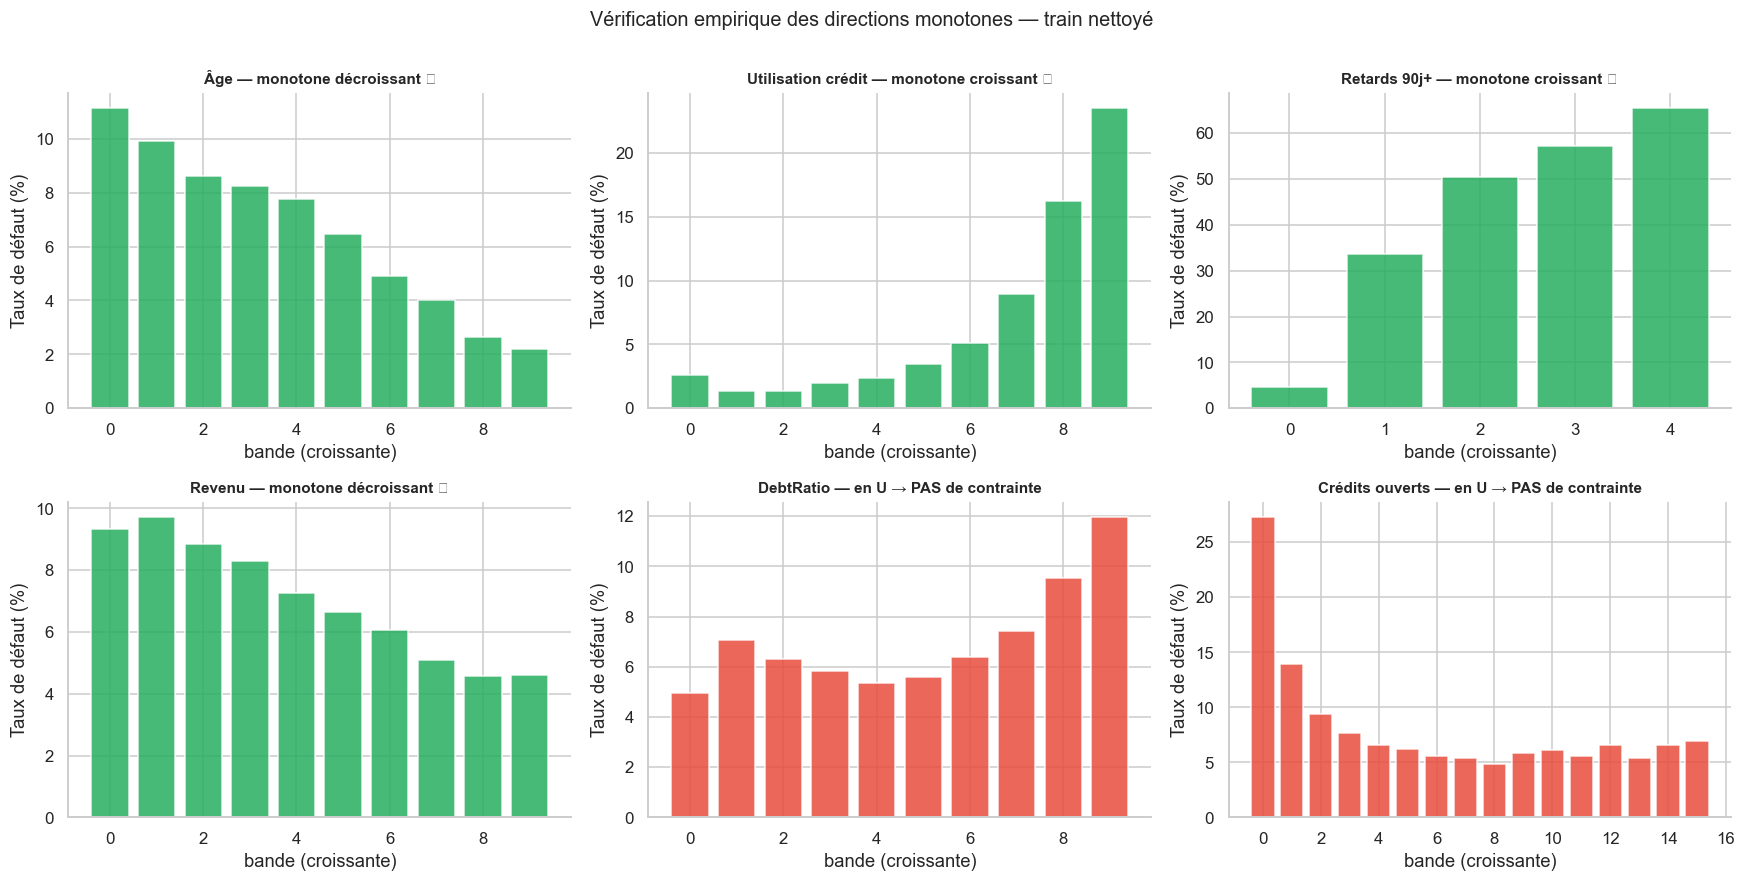

In [12]:
# Visualisation : monotone net vs relation en U
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
panels = [('age', 'Âge — monotone décroissant ✓'),
          ('RevolvingUtilizationOfUnsecuredLines', 'Utilisation crédit — monotone croissant ✓'),
          ('NumberOfTimes90DaysLate', 'Retards 90j+ — monotone croissant ✓'),
          ('MonthlyIncome', 'Revenu — monotone décroissant ✓'),
          ('DebtRatio', 'DebtRatio — en U → PAS de contrainte'),
          ('NumberOfOpenCreditLinesAndLoans', 'Crédits ouverts — en U → PAS de contrainte')]
for ax, (col, titre) in zip(axes.flat, panels):
    r = courbes[col]
    couleur = '#e74c3c' if 'PAS' in titre else '#27ae60'
    ax.bar(range(len(r)), r.values*100, color=couleur, alpha=.85, edgecolor='white')
    ax.set_title(titre, fontsize=10)
    ax.set_ylabel('Taux de défaut (%)')
    ax.set_xlabel('bande (croissante)')
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Vérification empirique des directions monotones — train nettoyé', fontsize=13, y=1.0)
plt.tight_layout()
plt.savefig('figures/fig_R02_monotonic_verification.png', dpi=120, bbox_inches='tight')
plt.show()

### Lecture des résultats

- **Confirmées et imposées** : `age` (−1, 0 % de paires croissantes : décroissance parfaite),
  `RevolvingUtilization` (+1, 89 %), les trois compteurs de retards (+1, 100 % chacun),
  `MonthlyIncome` (−1, 22 % croissantes = 78 % décroissantes), `NumberOfDependents` (+1, 80 %),
  et les deux indicateurs (`delinq_info_missing` 6.6 %→60.5 %, `income_missing` 7.1 %→5.4 %).
- **Réfutées → libres** : `DebtRatio` (Spearman +0.06 seulement ; en U : les ratios ~0
  — dossier sans charge connue — défautent à 9.7 %, plus que la médiane),
  `NumberOfOpenCreditLinesAndLoans` (27 % de défaut à 0 crédit — « dossier mince » —
  minimum vers 8–10 crédits, remontée ensuite) et `NumberRealEstateLoansOrLines` (même forme).
  Imposer +1 ou −1 à ces trois variables contredirait les données.
- Anomalies mineures acceptées : premier décile d'utilisation (2.6 % → 1.3 %) et
  premier décile de revenu (9.3 % → 9.7 %) — nous acceptons que la contrainte lisse
  ces micro-inversions locales au profit d'un comportement globalement défendable.

## 7. Étape 6 — Sauvegarde des artefacts

- `data/processed/` : X/y train et test **nettoyés, winsorisés, non imputés, non scalés**
  (l'imputation et le scaling appartiennent aux pipelines de modèles de la phase 3).
- `models/` : préprocesseur fitté, liste des features, contraintes monotones vérifiées.

In [13]:
PROC = '../data/processed/'
MODELS = '../models/'
os.makedirs(PROC, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

X_train.to_csv(PROC + 'X_train.csv', index=False)
X_test.to_csv(PROC + 'X_test.csv', index=False)
y_train.rename(TARGET).to_csv(PROC + 'y_train.csv', index=False)
y_test.rename(TARGET).to_csv(PROC + 'y_test.csv', index=False)

with open(MODELS + 'preprocessor.pkl', 'wb') as f:
    pickle.dump(prep, f, protocol=4)
with open(MODELS + 'feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f, protocol=4)
with open(MODELS + 'monotone_constraints.pkl', 'wb') as f:
    pickle.dump(MONOTONE_CONSTRAINTS, f, protocol=4)

print('Artefacts sauvegardés :')
for d in [PROC, MODELS]:
    for fname in sorted(os.listdir(d)):
        print(f"  {d}{fname:<28} {os.path.getsize(d+fname)/1024:>9.1f} KB")

Artefacts sauvegardés :
  ../data/processed/X_test.csv                      1599.2 KB
  ../data/processed/X_train.csv                     6396.9 KB
  ../data/processed/y_test.csv                        87.6 KB
  ../data/processed/y_train.csv                      350.2 KB
  ../models/calibration_comparison_phase3.csv       0.4 KB
  ../models/calibration_table_test_phase4.csv       0.4 KB
  ../models/calibrator.pkl                     2.9 KB
  ../models/calibrator_logistic_regression.pkl       3.2 KB
  ../models/calibrator_random_forest.pkl       0.7 KB
  ../models/cv_results_phase3.csv              0.4 KB
  ../models/decision_threshold.pkl             0.0 KB
  ../models/feature_cols.pkl                   0.3 KB
  ../models/metadata_final.pkl                 3.0 KB
  ../models/model_final.pkl                 1348.9 KB
  ../models/model_logistic_regression.pkl       2.1 KB
  ../models/model_random_forest.pkl        27167.0 KB
  ../models/monotone_constraints.pkl           0.3 KB
  ../mode

## 8. Synthèse

| Étape | Résultat |
|---|---|
| Nettoyage structurel | 150 000 → 149 390 lignes (1 age=0 + 609 doublons) |
| Split stratifié 80/20 | Train 119 512 / Test 29 878 — défaut 6.700 % / 6.701 % |
| Nettoyage sémantique | Sentinelles 96/98 → NaN + flag ; revenus ≤1 → NaN ; DebtRatio invalide → NaN ; utilisation >2 → NaN |
| Winsorisation (fit train) | Revenu p99.5, DebtRatio p99, Dependents p99.9 — chaque seuil justifié §4 |
| Features finales | 10 originales + `delinq_info_missing` + `income_missing` = **12** |
| Contraintes monotones | 9 imposées (vérifiées empiriquement), 3 réfutées et laissées libres |
| Cible | `SeriousDlqin2yrs` binaire — les classes applicatives viendront de la probabilité calibrée (phase 6) |

**Prochaine étape → Phase 3 (notebook 03) :** Logistic Regression, Random Forest, XGBoost —
pipelines par modèle (imputation/scaling internes à la CV), tuning par CV stratifiée 5-fold
sur le train, comparaison ROC-AUC / PR-AUC / recall / F1 / matrices de confusion.